# Autoencoder applied to an ensemble dispersion forecast

## Network training

### General configuration

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchsummary import summary
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

In [5]:
### Configuration ###
BATCH_SIZE    = 12
LATENT_DIM    = 2
LEARNING_RATE = 1E-3
NUM_EPOCHS    = 100
FNAME_MODEL   = 'autoencoder.pt'

### 1. Loading raw data and normalization

In [3]:
fname = 'tephra_col_mass.nc'
ds = xr.open_dataset(fname)

In [4]:
da = ds["tephra_col_mass"]

<xarray.DataArray 'tephra_col_mass' ()> Size: 4B
array(134.43684, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B ...

#### Standardization
Transformation so data is centered around 0 with variance ≈ 1:

$ x' = \dfrac{x-\mu}{\sigma + \epsilon}$

Choose `ε ~ 1e-6` or smaller, just to avoid division by zero

#### Simple scaling
Simple transformation resulting in positive values:

$ x' = \dfrac{x-x_{min}}{x_{max}-x_{min}}$

where $x_{min}$ are $x_{max}$ are global minimum and maximum values

In [5]:
class Standardize:
    def __init__(self, mean, std, eps=1e-6):
        self.mean = mean
        self.std = std
        self.eps = eps

    def __call__(self, x):
        return (x - self.mean) / (self.std + self.eps)

    def invert(self, x):
        return x * (self.std + self.eps) + self.mean

class MinMaxScale:
    def __init__(self, min_value, max_value):
        self.min = min_value
        self.max = max_value

    def __call__(self, x):
        return (x - self.min) / (self.max - self.min)

    def invert(self, x):
        return x * (self.max - self.min) + self.min

In [6]:
transform = MinMaxScale(0, 25)

### 2. Create a custom Dataset and splitting

A custom Dataset class must implement three functions: 
- `__init__`,
- `__len__`, and
- `__getitem__`

In [7]:
class EnsembleDataset(Dataset):
    def __init__(self, data_array, transform = None):
        self.X = data_array.values
        self.transform = transform
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = self.X[idx]
        x = torch.as_tensor(x, dtype=torch.float32)
        if self.transform:
            x = self.transform(x)
        x = x.unsqueeze(0)  # add channel dimension
        return x

* Training dataset: Used to optimize the model parameters (learn weights)
* Validation dataset: Used during training to monitor performance (used for hyperparameter tuning, early stopping, etc...)
* Test dataset: Used once to evaluate the final chosen model for a fair (unbiased) reporting of model performance

In [8]:
dataset = EnsembleDataset(da, transform)

# Random split with in training and validation datasets
n_total = len(dataset)
n_train = int(0.8 * n_total)   # 80% train
n_val   = n_total - n_train    # 20% val

train_dataset, val_dataset = random_split(dataset, [n_train, n_val])

### 3. Create a DataLoader
While training a model, we typically want to pass samples in "minibatches". `DataLoader` is an iterable that abstracts this complexity for us in an easy API:

In [9]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
for batch in train_loader:
    print(batch.shape)
    print(batch.max(), batch.min())
    break

torch.Size([12, 1, 101, 121])
tensor(4.1395) tensor(0.)


### 4. Define a model

Formula for output dims calculation in a Conv2d layer:

$ n_{out} = \lfloor \dfrac{n_{in} + 2p - k}{s} \rfloor + 1$

* k: convolution kernel size
* p: convolution padding size
* s: convolution stride size

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        ### Encoder ###
        self.encoder = nn.Sequential(
                nn.Conv2d(1,16,kernel_size=3, stride=2, padding=1), # N,16,51,61
                nn.ReLU(True),
                nn.Conv2d(16,32,kernel_size=3, stride=2, padding=1), #N,32,26,31
                nn.ReLU(True),
                nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), #N,64,13,16
                nn.ReLU(True),
                nn.Flatten(),
                nn.Linear(64*13*16,latent_dim)
                )

        ### Decoder ###
        self.decoder = nn.Sequential(
                nn.Linear(latent_dim, 64*13*16),
                nn.ReLU(True),
                nn.Unflatten(1, (64,13,16)),
                nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=(1,0)),
                nn.ReLU(True),
                nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=(0,0)),
                nn.ReLU(True),
                nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=(0,0)),
                nn.ReLU(True)
                )
    
    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

    def encode(self,x):
        return self.encoder(x)

    def decode(self,z):
        return self.decoder(z)

In [11]:
model = Autoencoder(LATENT_DIM)
summary(model, (1,101,121))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 51, 61]             160
              ReLU-2           [-1, 16, 51, 61]               0
            Conv2d-3           [-1, 32, 26, 31]           4,640
              ReLU-4           [-1, 32, 26, 31]               0
            Conv2d-5           [-1, 64, 13, 16]          18,496
              ReLU-6           [-1, 64, 13, 16]               0
           Flatten-7                [-1, 13312]               0
            Linear-8                    [-1, 2]          26,626
            Linear-9                [-1, 13312]          39,936
             ReLU-10                [-1, 13312]               0
        Unflatten-11           [-1, 64, 13, 16]               0
  ConvTranspose2d-12           [-1, 32, 26, 31]          18,464
             ReLU-13           [-1, 32, 26, 31]               0
  ConvTranspose2d-14           [-1, 16,

In [13]:
model.eval()

with torch.no_grad():
    for batch in train_loader:
        prediction = model(batch)
        print(prediction.shape)
        break

torch.Size([12, 1, 101, 121])


### 5. Training function

In [14]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for batch in loader:
        optimizer.zero_grad()
        prediction = model(batch)
        loss = criterion(prediction,batch)
        loss.backward()
        optimizer.step()
        
        # Get current batch size
        current_batch_size = batch.size(0)
        total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

In [15]:
def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            prediction = model(batch)
            loss = criterion(prediction,batch)

            # Get current batch size
            current_batch_size = batch.size(0)
            total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

## Training loop

In [16]:
criterion = nn.MSELoss(reduction="mean")
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [17]:
train_losses = []
val_losses = []
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss   = evaluate_epoch(model, val_loader, criterion)
    # Store current losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)    
    print(f"Epoch {epoch+1:02d} -> Train loss {train_loss:.4f} | Test loss: {val_loss:.4f}")

Epoch 01 -> Train loss 0.0663 | Test loss: 0.0770
Epoch 02 -> Train loss 0.0577 | Test loss: 0.0708
Epoch 03 -> Train loss 0.0524 | Test loss: 0.0648
Epoch 04 -> Train loss 0.0461 | Test loss: 0.0495
Epoch 05 -> Train loss 0.0325 | Test loss: 0.0318
Epoch 06 -> Train loss 0.0199 | Test loss: 0.0217
Epoch 07 -> Train loss 0.0143 | Test loss: 0.0157
Epoch 08 -> Train loss 0.0121 | Test loss: 0.0143
Epoch 09 -> Train loss 0.0108 | Test loss: 0.0127
Epoch 10 -> Train loss 0.0094 | Test loss: 0.0108
Epoch 11 -> Train loss 0.0081 | Test loss: 0.0096
Epoch 12 -> Train loss 0.0073 | Test loss: 0.0087
Epoch 13 -> Train loss 0.0068 | Test loss: 0.0084
Epoch 14 -> Train loss 0.0065 | Test loss: 0.0080
Epoch 15 -> Train loss 0.0062 | Test loss: 0.0075
Epoch 16 -> Train loss 0.0059 | Test loss: 0.0072
Epoch 17 -> Train loss 0.0059 | Test loss: 0.0069
Epoch 18 -> Train loss 0.0056 | Test loss: 0.0068
Epoch 19 -> Train loss 0.0054 | Test loss: 0.0066
Epoch 20 -> Train loss 0.0053 | Test loss: 0.0067


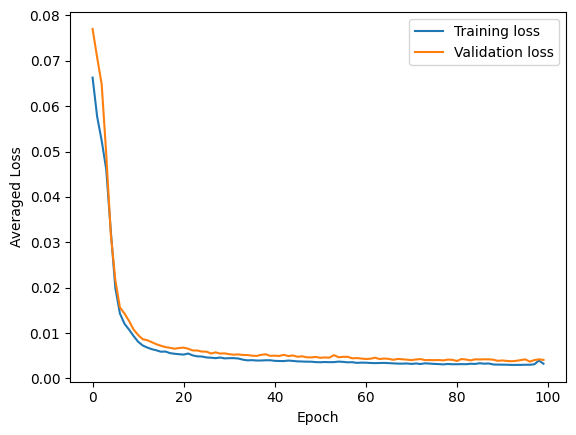

In [18]:
plt.plot(train_losses, label = 'Training loss')
plt.plot(val_losses, label = 'Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Averaged Loss')
plt.legend()

## Save trained model

In [19]:
#torch.save(model.state_dict(), FNAME_MODEL)

## State reconstruction

In [20]:
model.eval()

plot_conf = {
    'cmap': 'RdYlBu_r',
    'vmin': 0, 
    'vmax': 30,
}

xp_list = []
xv_list = []
with torch.no_grad():
    for batch in val_loader:
        prediction = model(batch)
        xp = prediction.squeeze(1)
        xv = batch.squeeze(1)
        xp_list.append(transform.invert(xp))
        xv_list.append(transform.invert(xv))
    xp = torch.cat(xp_list, dim=0)
    xv = torch.cat(xv_list, dim=0)

In [21]:
# Create xarray Dataset
ds_validation = xr.Dataset(
    {
        "xp": (["sample", "lat", "lon"], xp.numpy()),
        "xv": (["sample", "lat", "lon"], xv.numpy()),
    },
    coords={
        "lat": da.lat,
        "lon": da.lon,
    }
)

In [22]:
ds_validation.to_netcdf("reconstruced_large.nc")

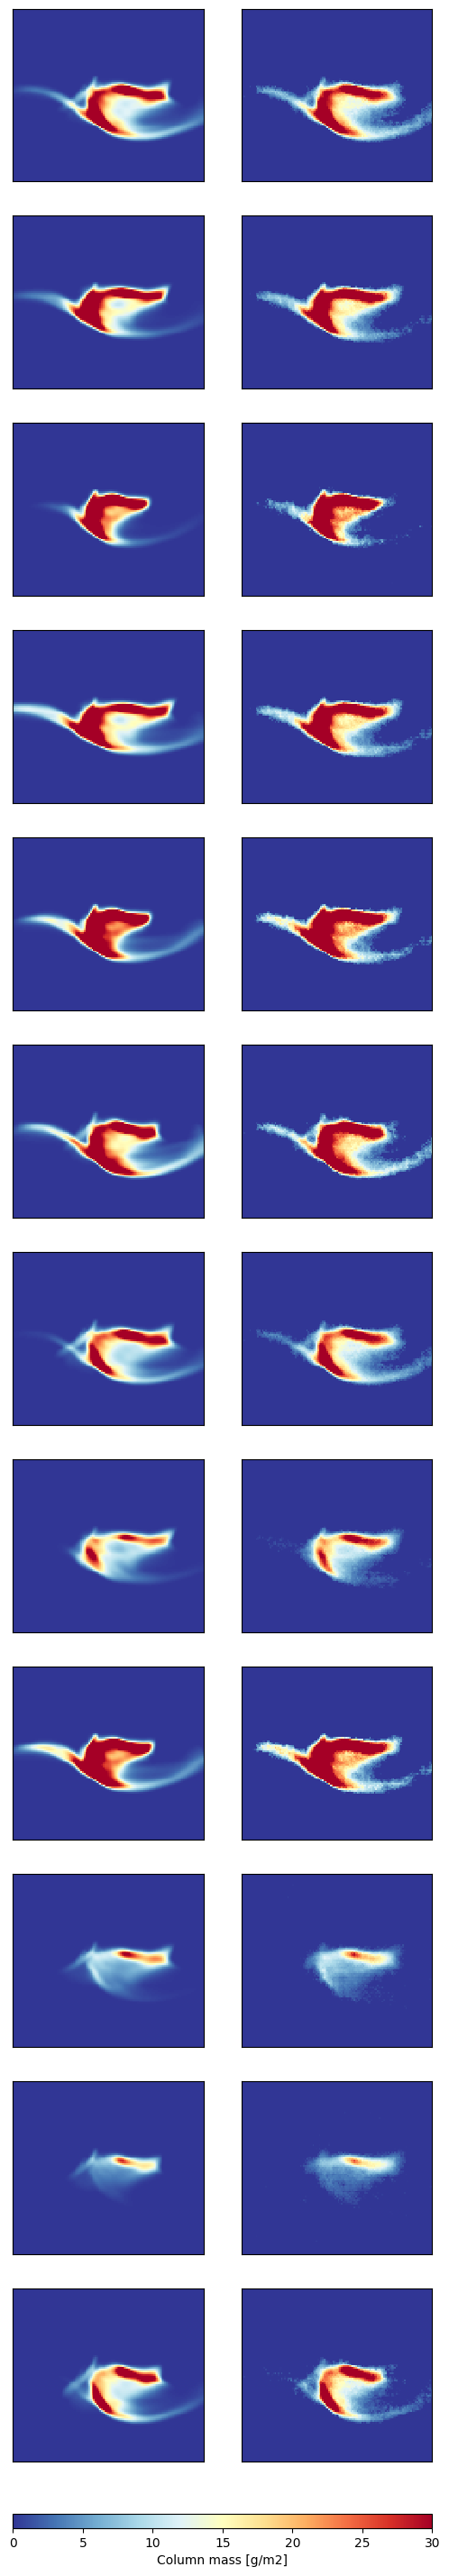

In [23]:
n=min(12,n_val)
fig, axs = plt.subplots(nrows = n, ncols = 2, figsize=(6,38))

for i in range(n):
    cs1=axs[i,0].pcolormesh(da.lon,da.lat,xv[i], **plot_conf)
    cs2=axs[i,1].pcolormesh(da.lon,da.lat,xp[i], **plot_conf)
                        
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    
cbar = fig.colorbar(cs2, 
             ax=axs, 
             orientation='horizontal',
             fraction=0.05,
             pad=0.02, 
             aspect=30
            )
cbar.set_label('Column mass [g/m2]')

## Latent Space Visualization

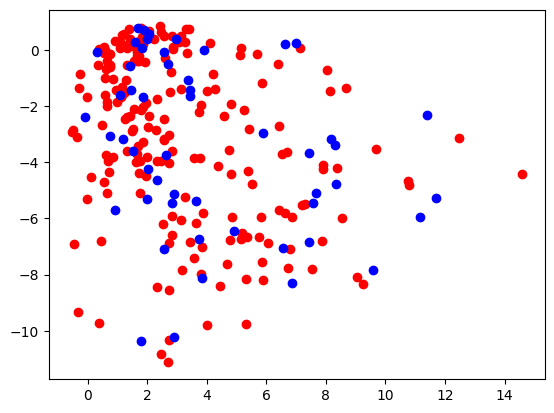

In [24]:
model.eval()

fig, ax = plt.subplots()

with torch.no_grad():
    for batch in train_loader:
        z = model.encode(batch)
        ax.scatter(z[:,0],z[:,1], color='red')
    for batch in val_loader:
        z = model.encode(batch)
        ax.scatter(z[:,0],z[:,1], color='blue')

In [27]:
model.eval()

z = torch.tensor([[6,-4]], dtype=torch.float32)
with torch.no_grad():
    new_sample = model.decode(z)
    x = transform.invert(new_sample).squeeze()

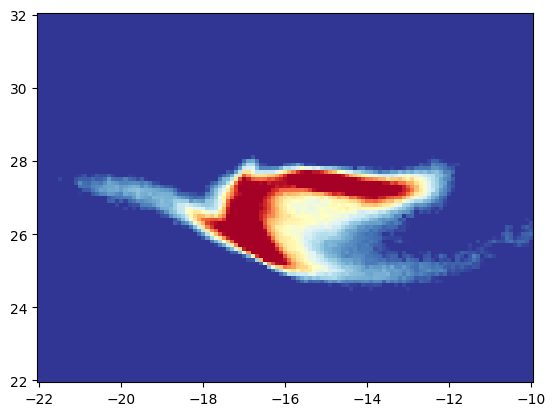

In [28]:
fig, ax = plt.subplots()
ax.pcolormesh(da.lon,da.lat,x,**plot_conf)